# Experiment Results with TS2Vec variations

In [19]:
import pandas as pd
import functools as ft

### Load results

In [29]:
# UCR - 128 - Univariate -------------------
exp_ucr_dirs = {
    'ecg2vec': "../training/ecg2vec_UCR_20260206_102221",
    # 'ecg2vec-gelu': "../training/ecg2vec-gelu_UCR_20260123_101648", #
    # 'ecg2vec-all-sinelu': "../training/ecg2vec-all-sinelu_UCR_20260128_105519", #
    'ecg2vec-def': "../training/ecg2vec-def_UCR_20260127_143606",
    'ecg2vec-def-5d': "../training/ecg2vec-def-5d_UCR_20260210_000349",
    # 'ecg2vec-se': "../training/ecg2vec-se_UCR_20260204_202306", # 
    # 'ecg2vec-disjoint': "../training/!ecg2vec-disjoint_UCR_20260203_102018", #
    # 'ecg2vec-disjoint-5d': "../training/ecg2vec-disjoint-5d_UCR_20260219_172415", #
    # 'ecg2vec-djt-def': "../training/ecg2vec-djt-def_UCR_20260210_200159", #
    'ecg2vec-def-final': "../training/ecg2vec-def-final_UCR_20260205_191041",
    'ts2vec': "../training/ts2vec_UCR_20260112_075225",
    'ts2vec-5d': "../training/ts2vec-5d_UCR_20260220_162436",
}

# UEA - Multivariate -------------------
exp_uea_dirs = {
    'ecg2vec': "../training/ecg2vec_UEA_20260206_145200",
    # 'ecg2vec-gelu': "../training/ecg2vec-gelu_UEA_20260126_133102", #
    # 'ecg2vec-all-sinelu': "../training/ecg2vec-all-sinelu_UEA_20260126_181512", #
    # 'ecg2vec-def': "../training/ecg2vec-def_UEA_20260203_214937", #
    # 'ecg2vec-def-5d': "../training/ecg2vec-def-5d_UEA_20260209_184850", #
    'ecg2vec-se': "../training/ecg2vec-se_UEA_20260204_171739",
    'ecg2vec-disjoint': "../training/ecg2vec-disjoint_UEA_20260203_151124",
    'ecg2vec-disjoint-5d': "../training/ecg2vec-disjoint-5d_UEA_20260219_115105",
    'ecg2vec-djt-def': "../training/ecg2vec-djt-def_UEA_20260211_155631",
    # 'ecg2vec-def-final': "../training/ecg2vec-def-final_UEA_20260206_002727", #
    'ts2vec': "../training/ts2vec_UEA_20260127_010456",
}

In [30]:
def read_results(exp_dirs: dict):

    results = {}
    results_4cdd = {}

    for key, value in exp_dirs.items():
        exp_result = pd.read_csv(value+"/results.csv")

        exp_result['model'] = exp_result.run_name.combine(exp_result.classifier, lambda x, y: x + '+' + y)
        exp_result = exp_result[['model', 'dataset', 'acc', 'f1', 'recall', 'precision', 'auprc']].copy()
        exp_result = exp_result.groupby(by=['model', 'dataset'], as_index=False).mean()

        result_4cdd = exp_result[['dataset', 'acc']].copy()
        result_4cdd.rename({'acc': key}, axis=1, inplace=True)

        results[key] = exp_result
        results_4cdd[key] = result_4cdd

    return results, results_4cdd


results_ucr, results_ucr_4cdd = read_results(exp_ucr_dirs)
results_uea, results_uea_4cdd = read_results(exp_uea_dirs)

Merge all UCR metrics

In [31]:
metrics_ucr = ft.reduce(
    lambda left, right: pd.merge(left, right, on='dataset', how='inner'),
    results_ucr_4cdd.values()
)
metrics_ucr.set_index('dataset', inplace=True)
print("rows: ", len(metrics_ucr))
metrics_ucr.head()

rows:  128


,ecg2vec,ecg2vec-def,ecg2vec-def-5d,ecg2vec-def-final,ts2vec,ts2vec-5d
dataset,,,,,,
ACSF1,0.852000,0.854000,0.870000,0.858000,0.866000,0.890000
Adiac,0.794885,0.782609,0.794373,0.776471,0.758056,0.757033
AllGestureWiimoteX,0.774000,0.779429,0.789429,0.754000,0.779143,0.780571
AllGestureWiimoteY,0.757429,0.761429,0.760857,0.754000,0.773714,0.782286
AllGestureWiimoteZ,0.764000,0.751143,0.760857,0.756000,0.761714,0.756286


Merge all UEA metrics

In [32]:
metrics_uea = ft.reduce(
    lambda left, right: pd.merge(left, right, on='dataset', how='inner'),
    results_uea_4cdd.values()
)
metrics_uea.set_index('dataset', inplace=True)
print("rows: ", len(metrics_uea))
metrics_uea.head()

rows:  30


,ecg2vec,ecg2vec-se,ecg2vec-disjoint,ecg2vec-disjoint-5d,ecg2vec-djt-def,ts2vec
dataset,,,,,,
ArticularyWordRecognition,0.960667,0.962667,0.966000,0.970667,0.958667,0.984000
AtrialFibrillation,0.240000,0.320000,0.293333,0.240000,0.320000,0.280000
BasicMotions,1.000000,1.000000,1.000000,1.000000,1.000000,0.980000
CharacterTrajectories,0.993175,0.989136,0.990111,0.992897,0.991365,0.993733
Cricket,0.966667,0.980556,0.966667,0.977778,0.958333,0.950000


### Visualization

In [33]:
import matplotlib.pyplot as plt
from labicompare.visualization import one_vs_one_plot, critical_difference_diagram

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'One vs One Comparison: ts2vec vs ecg2vec'}, xlabel='ts2vec performance', ylabel='ecg2vec performance'>)

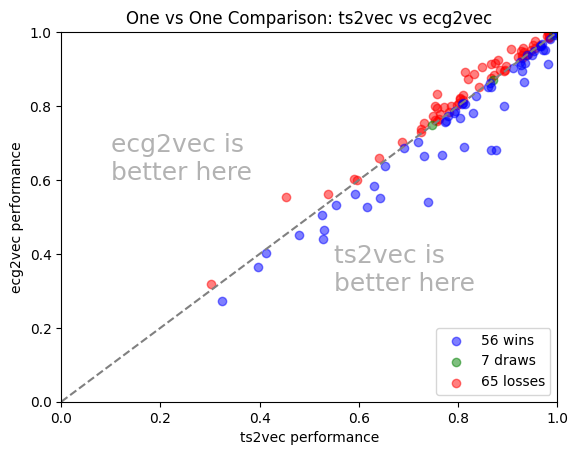

In [34]:
one_vs_one_plot(
    metrics_model_1=metrics_ucr['ts2vec'].values,
    metrics_model_2=metrics_ucr['ecg2vec'].values,
    model_1_name='ts2vec', model_2_name='ecg2vec'
)

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'One vs One Comparison: ts2vec vs ecg2vec'}, xlabel='ts2vec performance', ylabel='ecg2vec performance'>)

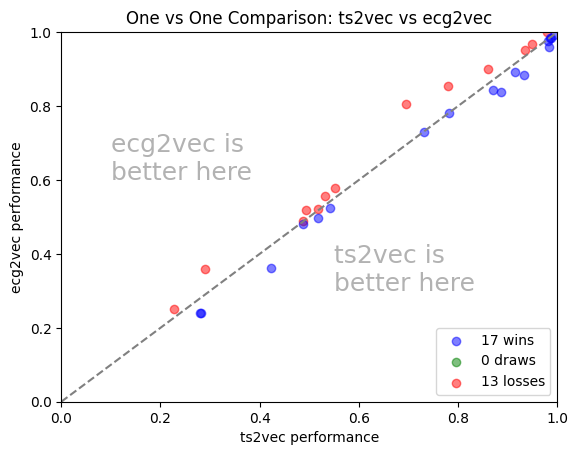

In [35]:
one_vs_one_plot(
    metrics_model_1=metrics_uea['ts2vec'].values,
    metrics_model_2=metrics_uea['ecg2vec'].values,
    model_1_name='ts2vec', model_2_name='ecg2vec'
)

Text(0.5, 1.0, 'UCR Datasets - Univariate (nemenyi)')

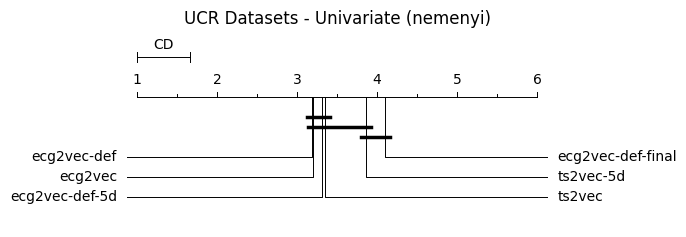

In [36]:
test = 'nemenyi'
# test = 'wilcoxon'

fig = critical_difference_diagram(
    metrics=metrics_ucr,
    test=test,
    alpha=0.05
)
plt.title(f'UCR Datasets - Univariate ({test})')

Text(0.5, 1.0, 'UEA Datasets - Multivariate (nemenyi)')

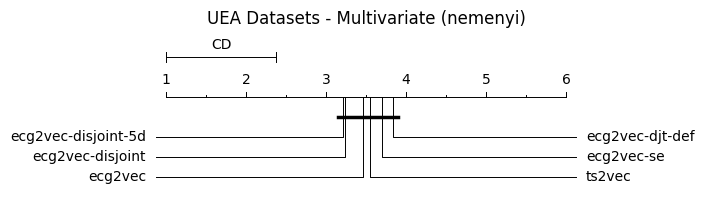

In [37]:
test = 'nemenyi'
# test = 'wilcoxon'

fig = critical_difference_diagram(
    metrics=metrics_uea,
    test=test,
    alpha=0.05
)
plt.title(f'UEA Datasets - Multivariate ({test})')